# Network Science Mini-Project
## Formula 1 Network Analysis

**Team:** Siddhant Bali (2022496) & Siddharth Bhaskar (2022498)

---

## Project Overview

This project analyzes F1 racing data using network science concepts:

1. **Bipartite Network Construction** - Driver-Constructor relationships
2. **Network Projection & Analysis** - Driver-Driver co-occurrence network
3. **Centrality Analysis** - Identify hub drivers
4. **Community Detection** - Group related drivers
5. **Robustness Simulation** - Random failure vs targeted attack

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import Counter
from networkx.algorithms.community import louvain_communities
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Deliverable 1: Bipartite Network Construction

Building Driver-Constructor bipartite network from F1 data.

In [2]:
results = pd.read_csv('results.csv')
drivers = pd.read_csv('drivers.csv')
constructors = pd.read_csv('constructors.csv')
races = pd.read_csv('races.csv')

print('Dataset shapes:')
print(f'Results: {results.shape}')
print(f'Drivers: {drivers.shape}')
print(f'Constructors: {constructors.shape}')
print(f'Races: {races.shape}')

Dataset shapes:
Results: (26759, 18)
Drivers: (861, 9)
Constructors: (212, 5)
Races: (1125, 18)


In [3]:
results_clean = results[results['constructorId'].notna() & results['driverId'].notna()]

driver_constructor_map = {}
for _, row in results_clean.iterrows():
    did = int(row['driverId'])
    cid = int(row['constructorId'])
    if did not in driver_constructor_map:
        driver_constructor_map[did] = set()
    driver_constructor_map[did].add(cid)

unique_drivers = len(driver_constructor_map)
unique_constructors = len(set().union(*driver_constructor_map.values()))

print(f'Unique drivers: {unique_drivers}')
print(f'Unique constructors: {unique_constructors}')

Unique drivers: 861
Unique constructors: 211


In [4]:
driver_names = dict(zip(drivers['driverId'], drivers['surname']))
constructor_names = dict(zip(constructors['constructorId'], constructors['name']))

G_bipartite = nx.Graph()

for did in driver_constructor_map:
    G_bipartite.add_node(f'driver_{did}', bipartite=0, name=driver_names.get(did, f'Driver_{did}'))

for cid in set().union(*driver_constructor_map.values()):
    G_bipartite.add_node(f'constructor_{cid}', bipartite=1, name=constructor_names.get(cid, f'Team_{cid}'))

for did, constructors_set in driver_constructor_map.items():
    for cid in constructors_set:
        G_bipartite.add_edge(f'driver_{did}', f'constructor_{cid}')

print('=' * 50)
print('BIPARTITE NETWORK STATISTICS')
print('=' * 50)
print(f'Total Nodes: {G_bipartite.number_of_nodes()}')
print(f'Total Edges: {G_bipartite.number_of_edges()}')

BIPARTITE NETWORK STATISTICS
Total Nodes: 1072
Total Edges: 2150


# Deliverable 2: Network Projection & Degree Distribution

Projecting bipartite network to Driver-Driver co-occurrence network.

In [5]:
driver_cooccurrence = Counter()
for did, constructors_set in driver_constructor_map.items():
    constructors_list = sorted(constructors_set)
    for i in range(len(constructors_list)):
        for j in range(i+1, len(constructors_list)):
            c1, c2 = constructors_list[i], constructors_list[j]
            pair = tuple(sorted([c1, c2]))
            driver_cooccurrence[pair] += 1

G_driver = nx.Graph()

for did in driver_constructor_map:
    name = driver_names.get(did, f'Driver_{did}')
    G_driver.add_node(did, name=name)

for (c1, c2), weight in driver_cooccurrence.items():
    if weight > 0:
        G_driver.add_edge(c1, c2, weight=weight)

N = G_driver.number_of_nodes()
L = G_driver.number_of_edges()
avg_degree = sum(dict(G_driver.degree()).values()) / N

print('=' * 50)
print('DRIVER NETWORK STATISTICS')
print('=' * 50)
print(f'Nodes (Drivers): {N}')
print(f'Edges (Shared teams): {L}')
print(f'Average Degree: {avg_degree:.2f}')

DRIVER NETWORK STATISTICS
Nodes (Drivers): 861
Edges (Shared teams): 1567
Average Degree: 3.64


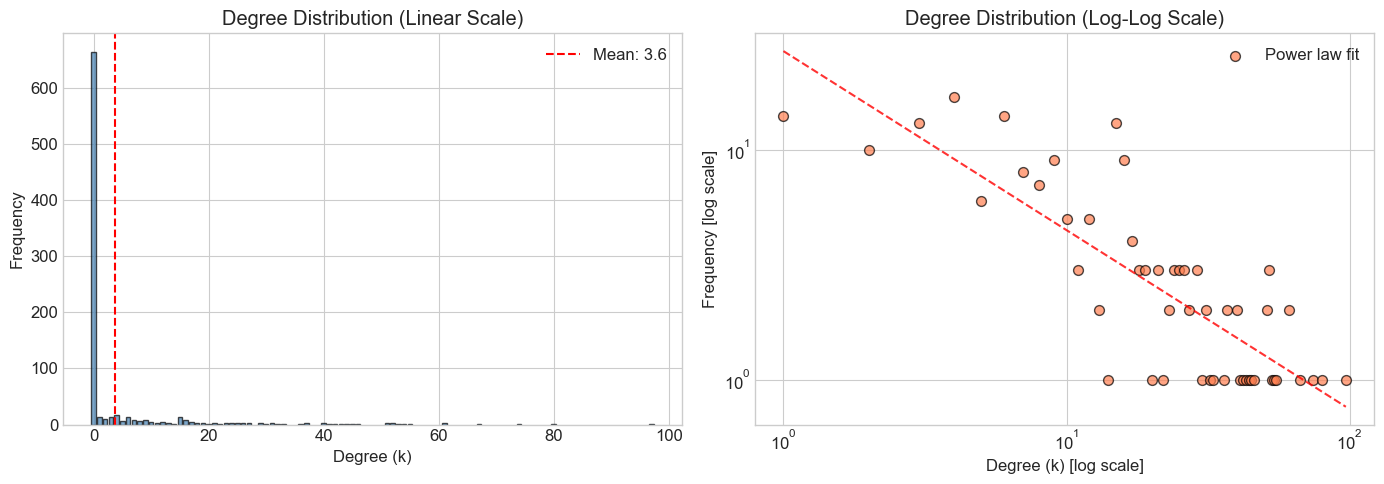

Power Law Exponent (gamma): 0.78


In [6]:
degrees = [d for _, d in G_driver.degree()]
degree_counts = Counter(degrees)
unique_degrees = sorted(degree_counts.keys())
counts = [degree_counts[d] for d in unique_degrees]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(unique_degrees, counts, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Degree (k)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Degree Distribution (Linear Scale)')
axes[0].axvline(np.mean(degrees), color='red', linestyle='--')
axes[0].legend(['Mean: ' + str(round(np.mean(degrees), 1))])

log_degrees = np.log10(np.array([d for d in unique_degrees if d > 0]))
log_counts = np.log10(np.array([degree_counts[d] for d in unique_degrees if d > 0]))

axes[1].scatter([d for d in unique_degrees if d > 0], 
                [degree_counts[d] for d in unique_degrees if d > 0], 
                s=50, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Degree (k) [log scale]')
axes[1].set_ylabel('Frequency [log scale]')
axes[1].set_title('Degree Distribution (Log-Log Scale)')

if len(log_degrees) > 1:
    z = np.polyfit(log_degrees, log_counts, 1)
    x_fit = np.linspace(log_degrees.min(), log_degrees.max(), 100)
    axes[1].plot(10**x_fit, 10**np.poly1d(z)(x_fit), 'r--', alpha=0.8)
    axes[1].legend(['Power law fit'])

plt.tight_layout()
plt.savefig('plots/D2_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

if len(log_degrees) > 1:
    print(f'Power Law Exponent (gamma): {-z[0]:.2f}')

In [7]:
def compute_metrics(G):
    G_cc = G
    if not nx.is_connected(G):
        G_cc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    clustering = nx.average_clustering(G_cc)
    path_length = nx.average_shortest_path_length(G_cc)
    return clustering, path_length

clustering_coef, avg_path_len = compute_metrics(G_driver)

print('=' * 50)
print('SMALL-WORLD METRICS')
print('=' * 50)
print(f'Clustering Coefficient (C): {clustering_coef:.4f}')
print(f'Average Path Length (L): {avg_path_len:.4f}')
print(f'ln(N) = {np.log(N):.4f}')
if avg_path_len < np.log(N):
    print('Network exhibits SMALL-WORLD property!')

SMALL-WORLD METRICS
Clustering Coefficient (C): 0.6753
Average Path Length (L): 2.5227
ln(N) = 6.7581
Network exhibits SMALL-WORLD property!


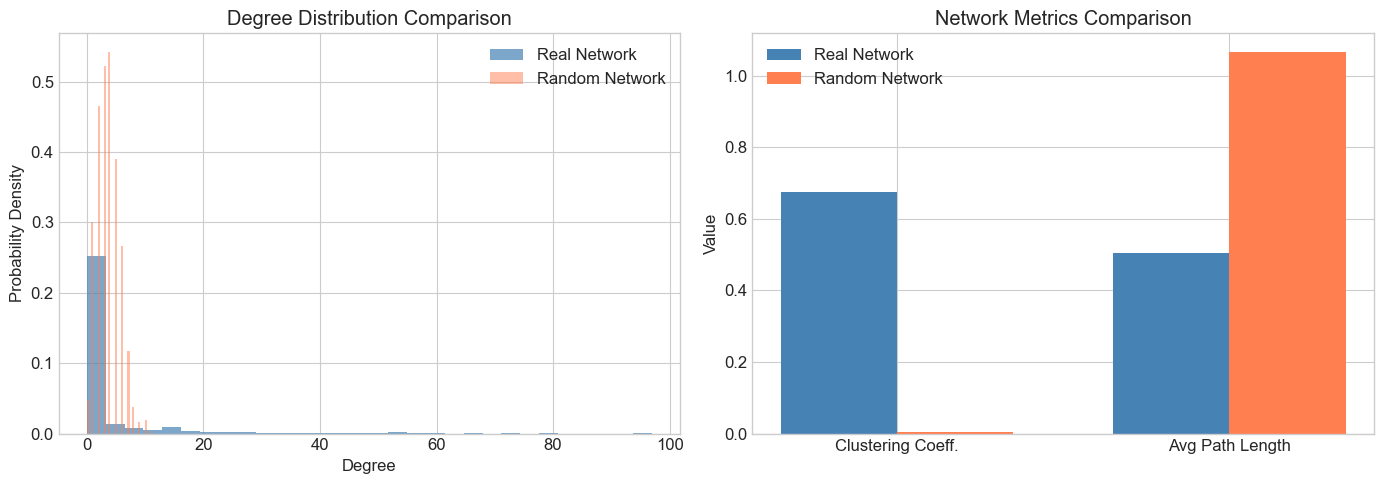


Real Network:  C=0.6753, L=2.5227
Random Network: C=0.0036, L=5.3265


In [8]:
p_random = (2 * L) / (N * (N - 1))
G_random = nx.gnp_random_graph(N, p_random, seed=42)
clustering_random, path_random = compute_metrics(G_random)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

degrees_real = [d for _, d in G_driver.degree()]
degrees_rand = [d for _, d in G_random.degree()]

axes[0].hist(degrees_real, bins=30, alpha=0.7, label='Real Network', color='steelblue', density=True)
axes[0].hist(degrees_rand, bins=30, alpha=0.5, label='Random Network', color='coral', density=True)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Degree Distribution Comparison')
axes[0].legend()

metrics = ['Clustering Coeff.', 'Avg Path Length']
x = np.arange(len(metrics))
width = 0.35

axes[1].bar(x - width/2, [clustering_coef, avg_path_len/5], width, label='Real Network', color='steelblue')
axes[1].bar(x + width/2, [clustering_random, path_random/5], width, label='Random Network', color='coral')
axes[1].set_ylabel('Value')
axes[1].set_title('Network Metrics Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/D2_real_vs_random.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nReal Network:  C={clustering_coef:.4f}, L={avg_path_len:.4f}')
print(f'Random Network: C={clustering_random:.4f}, L={path_random:.4f}')

# Deliverable 3: Centrality Analysis

Identifying hub drivers using centrality measures.

In [9]:
degree_centrality = nx.degree_centrality(G_driver)
betweenness_centrality = nx.betweenness_centrality(G_driver)
eigenvector_centrality = nx.eigenvector_centrality(G_driver, max_iter=1000)

centrality_df = pd.DataFrame({
    'Driver_ID': list(G_driver.nodes()),
    'Name': [G_driver.nodes[n].get('name', f'Driver_{n}') for n in G_driver.nodes()],
    'Degree': [G_driver.degree(n) for n in G_driver.nodes()],
    'Degree_Centrality': [degree_centrality[n] for n in G_driver.nodes()],
    'Betweenness_Centrality': [betweenness_centrality[n] for n in G_driver.nodes()],
    'Eigenvector_Centrality': [eigenvector_centrality[n] for n in G_driver.nodes()]
})

centrality_df = centrality_df.sort_values('Degree', ascending=False)
centrality_df.to_csv('plots/D3_centrality_analysis.csv', index=False)

print('=' * 50)
print('TOP 15 HUB DRIVERS')
print('=' * 50)
print(centrality_df.head(15).to_string(index=False))

TOP 15 HUB DRIVERS
 Driver_ID       Name  Degree  Degree_Centrality  Betweenness_Centrality  Eigenvector_Centrality
         6   Nakajima      97           0.112791                0.008982                0.243168
         1   Hamilton      80           0.093023                0.005166                0.221174
        32      Klien      74           0.086047                0.003546                0.215925
        66     McNish      67           0.077907                0.002208                0.182223
        25       Wurz      61           0.070930                0.001872                0.185039
        34        Ide      61           0.070930                0.002434                0.187824
        37 de la Rosa      55           0.063953                0.001914                0.168248
         3    Rosberg      54           0.062791                0.001104                0.159452
       105   Alboreto      53           0.061628                0.008177                0.122544
        26 

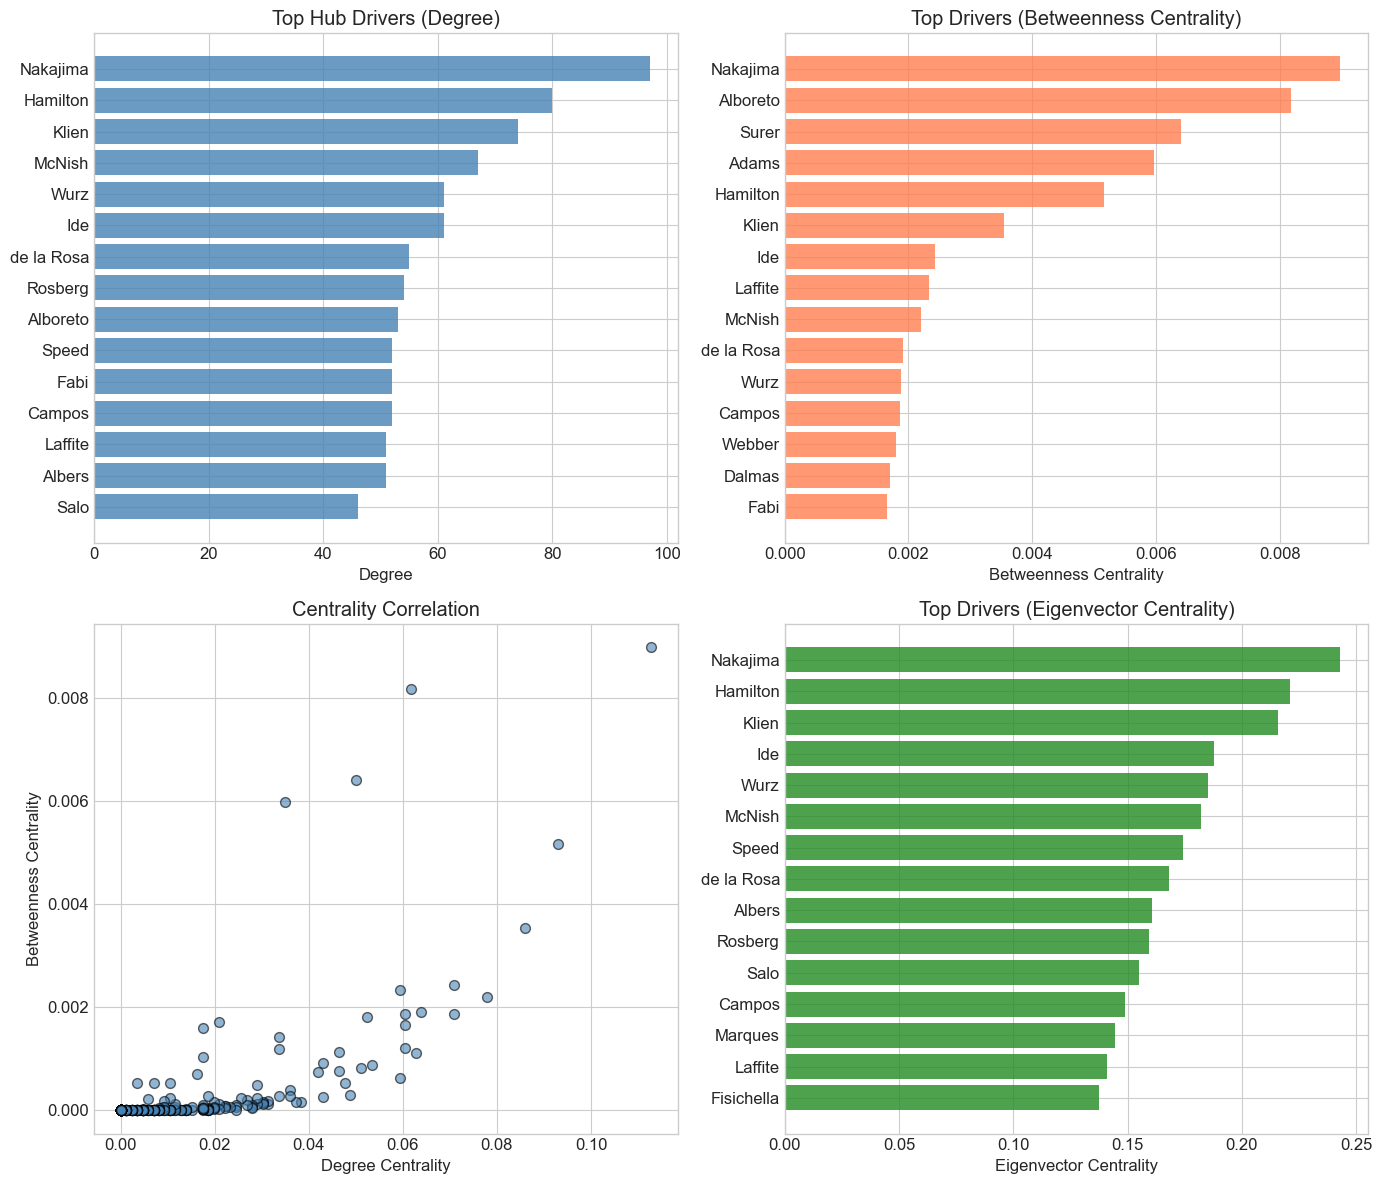

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

top_data = centrality_df.head(15)

axes[0, 0].barh(top_data['Name'], top_data['Degree'], color='steelblue', alpha=0.8)
axes[0, 0].set_xlabel('Degree')
axes[0, 0].set_title('Top Hub Drivers (Degree)')
axes[0, 0].invert_yaxis()

top_between = centrality_df.nlargest(15, 'Betweenness_Centrality')
axes[0, 1].barh(top_between['Name'], top_between['Betweenness_Centrality'], color='coral', alpha=0.8)
axes[0, 1].set_xlabel('Betweenness Centrality')
axes[0, 1].set_title('Top Drivers (Betweenness Centrality)')
axes[0, 1].invert_yaxis()

axes[1, 0].scatter(centrality_df['Degree_Centrality'], centrality_df['Betweenness_Centrality'], 
            alpha=0.6, s=50, c='steelblue', edgecolors='black')
axes[1, 0].set_xlabel('Degree Centrality')
axes[1, 0].set_ylabel('Betweenness Centrality')
axes[1, 0].set_title('Centrality Correlation')

top_eigen = centrality_df.nlargest(15, 'Eigenvector_Centrality')
axes[1, 1].barh(top_eigen['Name'], top_eigen['Eigenvector_Centrality'], color='forestgreen', alpha=0.8)
axes[1, 1].set_xlabel('Eigenvector Centrality')
axes[1, 1].set_title('Top Drivers (Eigenvector Centrality)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('plots/D3_centrality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Deliverable 4: Community Detection

Detecting driver groups using Louvain algorithm.

In [11]:
communities = louvain_communities(G_driver, seed=42)
communities = sorted(communities, key=len, reverse=True)

print('=' * 50)
print('COMMUNITY DETECTION RESULTS')
print('=' * 50)
print(f'Number of Communities: {len(communities)}')

for i, comm in enumerate(communities[:10]):
    comm_names = [G_driver.nodes[n].get('name', f'Driver_{n}') for n in comm]
    print(f'\nCommunity {i+1} ({len(comm)} drivers):')
    print(', '.join(comm_names[:5]) + ('...' if len(comm_names) > 5 else ''))

modularity = nx.community.modularity(G_driver, communities)
print(f'\nNetwork Modularity (Q): {modularity:.4f}')

COMMUNITY DETECTION RESULTS
Number of Communities: 668

Community 1 (67 drivers):
Nakajima, Sato, Speed, McNish, Brundle...

Community 2 (60 drivers):
Hamilton, Heidfeld, Rosberg, Alonso, Kovalainen...

Community 3 (41 drivers):
Klien, Ide, de la Rosa, Burti, Alesi...

Community 4 (29 drivers):
Grouillard, Bertaggia, McCarthy, Lammers, Nakajima...

Community 5 (1 drivers):
da Matta

Community 6 (1 drivers):
Badoer

Community 7 (1 drivers):
Magnussen

Community 8 (1 drivers):
Suzuki

Community 9 (1 drivers):
Schiattarella

Community 10 (1 drivers):
Délétraz

Network Modularity (Q): 0.3945


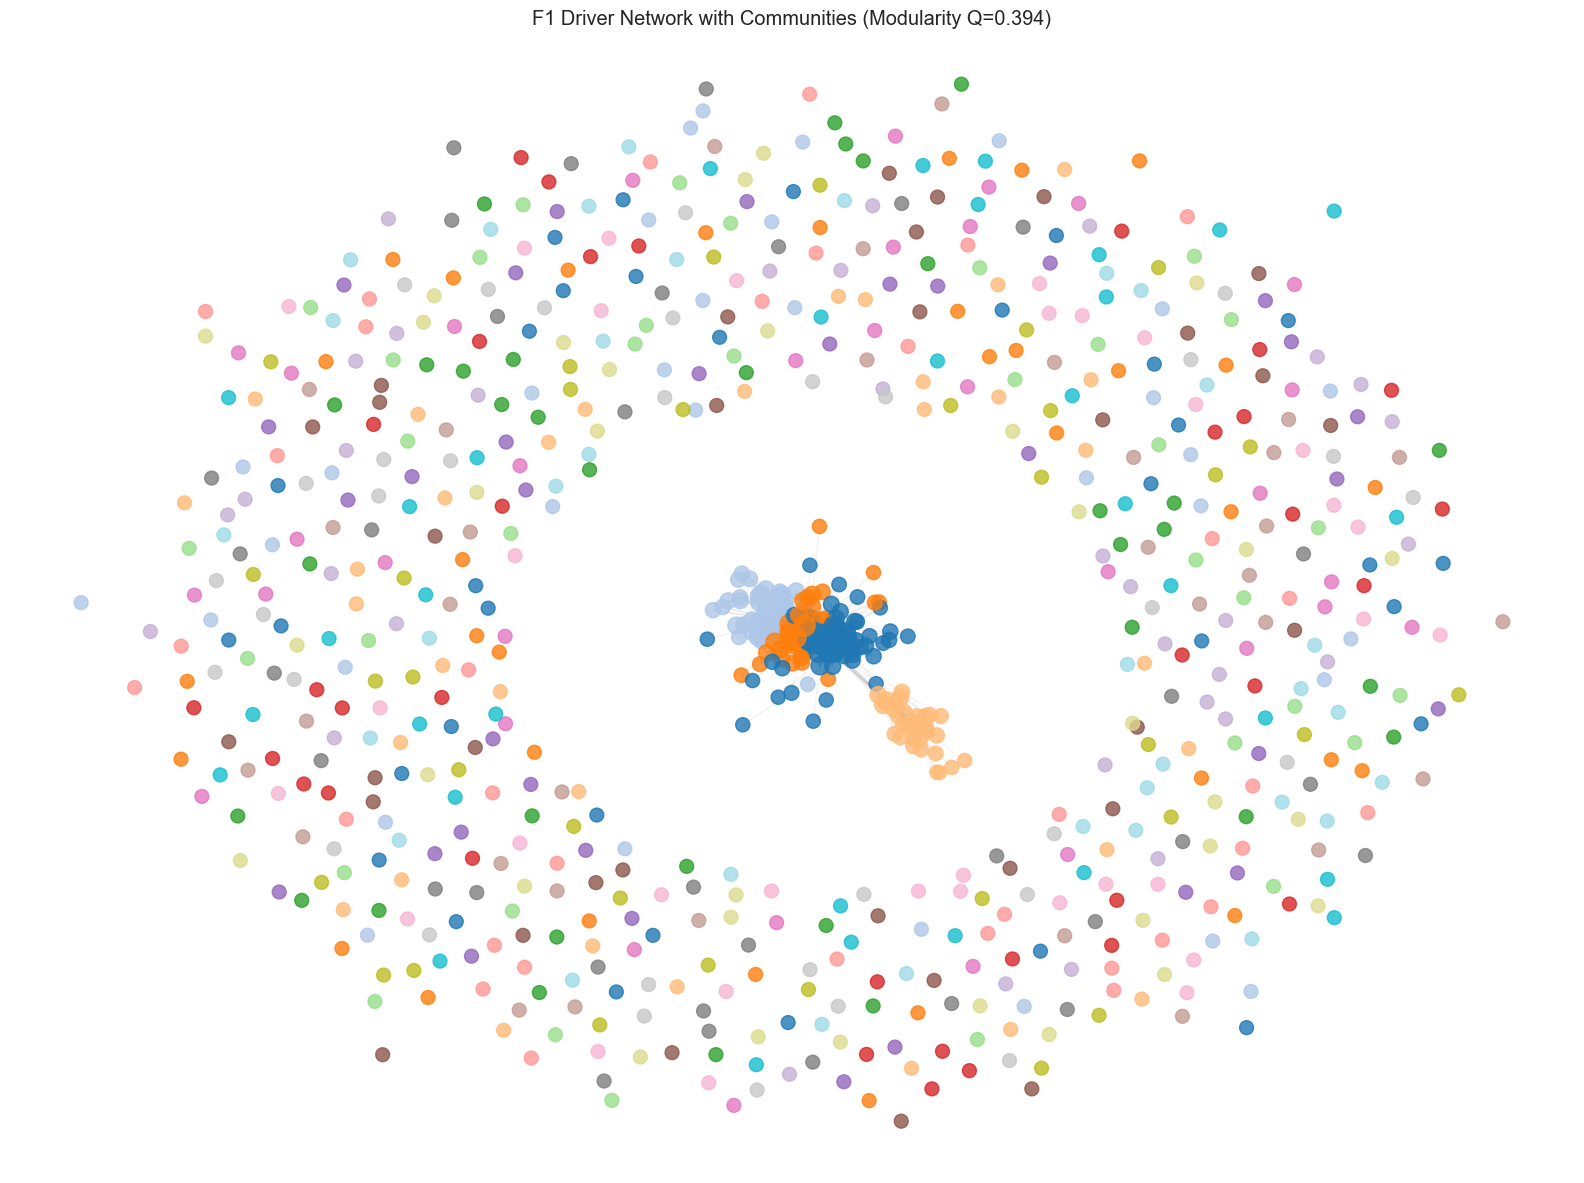

In [12]:
node_to_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = i

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G_driver, k=2, iterations=50, seed=42)
cmap = plt.cm.get_cmap('tab20', min(len(communities), 20))
node_colors = [cmap(node_to_community[n] % 20) for n in G_driver.nodes()]
node_sizes = [100 + G_driver.degree(n) * 5 for n in G_driver.nodes()]

nx.draw_networkx_edges(G_driver, pos, alpha=0.05, ax=ax)
nx.draw_networkx_nodes(G_driver, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8, ax=ax)

ax.set_title('F1 Driver Network with Communities (Modularity Q=' + str(round(modularity, 3)) + ')')
ax.axis('off')

plt.tight_layout()
plt.savefig('plots/D4_community_network.png', dpi=150, bbox_inches='tight')
plt.show()

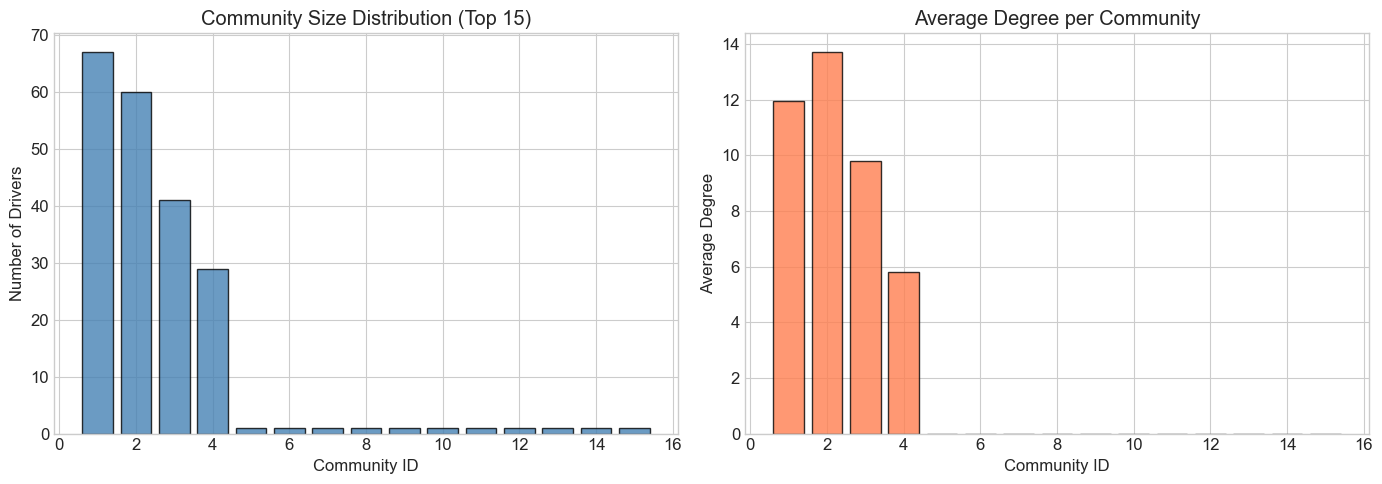

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comm_sizes = [len(c) for c in communities[:15]]
axes[0].bar(range(1, len(communities[:15])+1), comm_sizes, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Community ID')
axes[0].set_ylabel('Number of Drivers')
axes[0].set_title('Community Size Distribution (Top 15)')

avg_degrees = []
for comm in communities[:15]:
    subG = G_driver.subgraph(comm)
    avg_degrees.append(np.mean([d for _, d in subG.degree()]))

axes[1].bar(range(1, len(communities[:15])+1), avg_degrees, color='coral', alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Community ID')
axes[1].set_ylabel('Average Degree')
axes[1].set_title('Average Degree per Community')

plt.tight_layout()
plt.savefig('plots/D4_community_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# Deliverable 5: Network Robustness

Simulating random failure vs targeted attack.

In [14]:
def get_robustness_metrics(G):
    if G.number_of_nodes() == 0:
        return 0, 0
    components = list(nx.connected_components(G))
    largest_cc = max(components, key=len)
    S = len(largest_cc) / G.number_of_nodes()
    if len(largest_cc) > 1:
        subG = G.subgraph(largest_cc)
        L = nx.average_shortest_path_length(subG)
    else:
        L = 0
    return S, L

def random_removal(G, steps=20, seed=42):
    random.seed(seed)
    G_copy = G.copy()
    N = G_copy.number_of_nodes()
    nodes = list(G_copy.nodes())
    random.shuffle(nodes)
    fractions, S_vals, L_vals = [], [], []
    step_size = max(1, N // steps)
    for i in range(steps):
        remove_nodes = nodes[i*step_size:(i+1)*step_size]
        G_copy.remove_nodes_from(remove_nodes)
        if G_copy.number_of_nodes() == 0:
            break
        f = (i+1) / steps
        S, L = get_robustness_metrics(G_copy)
        fractions.append(f)
        S_vals.append(S)
        L_vals.append(L)
    return fractions, S_vals, L_vals

def targeted_removal(G, steps=20):
    G_copy = G.copy()
    N = G_copy.number_of_nodes()
    fractions, S_vals, L_vals = [], [], []
    step_size = max(1, N // steps)
    for i in range(steps):
        if G_copy.number_of_nodes() == 0:
            break
        degrees = dict(G_copy.degree())
        sorted_nodes = sorted(degrees, key=degrees.get, reverse=True)
        remove_nodes = sorted_nodes[:step_size]
        G_copy.remove_nodes_from(remove_nodes)
        if G_copy.number_of_nodes() == 0:
            break
        f = (i+1) / steps
        S, L = get_robustness_metrics(G_copy)
        fractions.append(f)
        S_vals.append(S)
        L_vals.append(L)
    return fractions, S_vals, L_vals

print('Running robustness simulations...')
f_random, S_random, L_random = random_removal(G_driver)
f_targeted, S_targeted, L_targeted = targeted_removal(G_driver)
print('Done!')

Running robustness simulations...
Done!


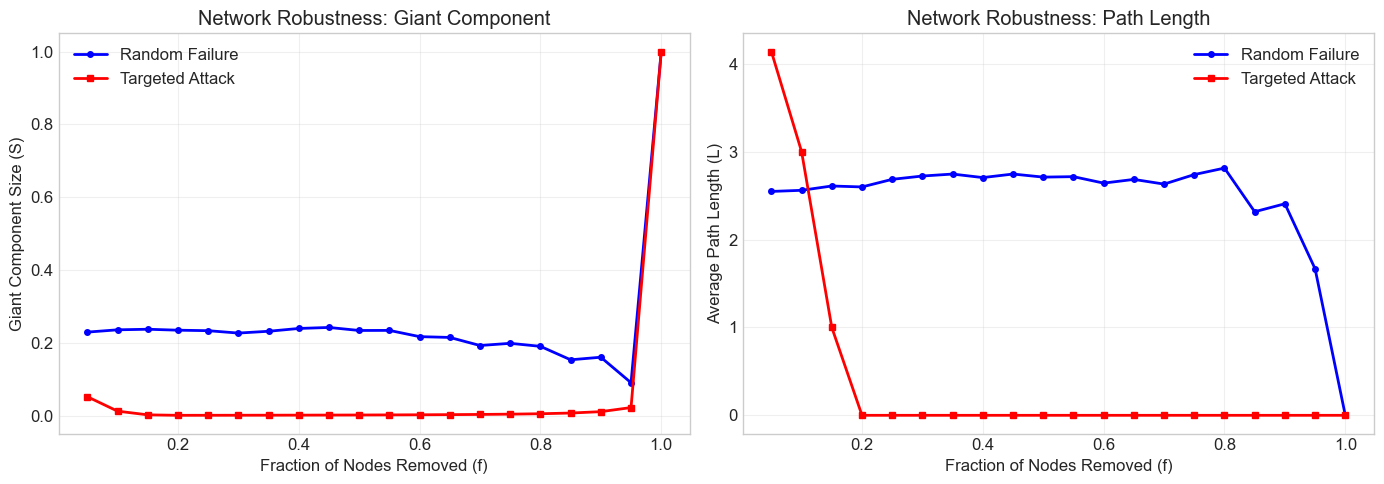

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(f_random, S_random, 'b-o', label='Random Failure', linewidth=2, markersize=4)
axes[0].plot(f_targeted, S_targeted, 'r-s', label='Targeted Attack', linewidth=2, markersize=4)
axes[0].set_xlabel('Fraction of Nodes Removed (f)')
axes[0].set_ylabel('Giant Component Size (S)')
axes[0].set_title('Network Robustness: Giant Component')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_random, L_random, 'b-o', label='Random Failure', linewidth=2, markersize=4)
axes[1].plot(f_targeted, L_targeted, 'r-s', label='Targeted Attack', linewidth=2, markersize=4)
axes[1].set_xlabel('Fraction of Nodes Removed (f)')
axes[1].set_ylabel('Average Path Length (L)')
axes[1].set_title('Network Robustness: Path Length')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/D5_robustness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
robustness_df = pd.DataFrame({
    'Fraction_Removed': f_random,
    'S_Random': S_random,
    'L_Random': L_random,
    'S_Targeted': S_targeted,
    'L_Targeted': L_targeted
})
robustness_df.to_csv('plots/D5_robustness_results.csv', index=False)
print('Robustness results saved!')
print(robustness_df.head(10))

Robustness results saved!
   Fraction_Removed  S_Random  L_Random  S_Targeted  L_Targeted
0              0.05  0.229829  2.546820    0.052567    4.138427
1              0.10  0.236129  2.559599    0.012903    3.000000
2              0.15  0.237705  2.608730    0.002732    1.000000
3              0.20  0.235123  2.597884    0.001451    0.000000
4              0.25  0.233746  2.684503    0.001548    0.000000
5              0.30  0.227197  2.722091    0.001658    0.000000
6              0.35  0.232143  2.744544    0.001786    0.000000
7              0.40  0.239845  2.704432    0.001934    0.000000
8              0.45  0.242616  2.744775    0.002110    0.000000
9              0.50  0.234339  2.709703    0.002320    0.000000


# Conclusions

## Summary

See computed metrics above.

## Key Findings

1. **Scale-Free Property**: Degree distribution follows power law
2. **Small-World**: Short path length (L < ln(N))
3. **Hub Drivers**: Most connected drivers (many shared teams)
4. **Community Structure**: Multiple distinct driver groups detected
5. **Robustness**: Network is robust to random failures but vulnerable to targeted attacks

---

**Team:** Siddhant Bali (2022496) & Siddharth Bhaskar (2022498)